In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import yfinance as yf
import talib as ta
import datetime as dt
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [2]:
# data 
stock1 = yf.Ticker('TD')
stock2 = yf.Ticker('RY')

training_start_date = dt.datetime(2018,1,1)
training_end_date = dt.datetime(2022,1,1)
testing_start_date = training_end_date
testing_end_date = dt.datetime.now()

P1 = stock1.history(start=training_start_date, end=testing_end_date)
P2 = stock2.history(start=training_start_date, end=testing_end_date)

# Get ln prices so that we look at % change not absolute $ change
P1['lnClose'] = np.log(P1['Close'])
P2['lnClose'] = np.log(P2['Close'])


In [3]:
# build df with relevant data -> date, lnP1, lnP2

df = pd.DataFrame({
    "P1": P1["lnClose"].values, # get values from ln columns
    "P2": P2["lnClose"].values,
})
df = df.set_index(P1.index)

# Remove timezone data from date array
df.index = pd.to_datetime(df.index).tz_localize(None)

df

,P1,P2
Date,,
2018-01-02,3.733357,4.101831
2018-01-03,3.737761,4.108007
2018-01-04,3.748854,4.120960
2018-01-05,3.757507,4.126663
2018-01-08,3.755019,4.122270
...,...,...
2026-06-30,4.799338,5.332574
2026-07-01,4.806068,5.339027
2026-07-02,4.781641,5.321985


In [4]:
# Linear regression on training data
# lnP1 = alpha + beta * lnP2 + residual

# Get price data within training period
train = df.loc[training_start_date:training_end_date].copy()

x_train = train['P1']
y_train = train['P2']

# Add intercept term column, else forced intercept at origin -> [const, P1]
x_train = sm.add_constant(x_train)

# fit Ordinary Least Squares model on x and y data -> returns value for const and slope 
model = sm.OLS(y_train, x_train).fit()

# assign intercept alpha and slope beta 
alpha = model.params['const'] # intercept
beta = model.params['P1'] # slope

print(f'alpha = {alpha}')
print(f'beta = {alpha}')
print(model.summary())

alpha = 0.5249014556830289
beta = 0.5249014556830289
                            OLS Regression Results                            
Dep. Variable:                     P2   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     9917.
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:46:25   Log-Likelihood:                 1567.5
No. Observations:                1008   AIC:                            -3131.
Df Residuals:                    1006   BIC:                            -3121.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [5]:
# Compute Residuals over time

# math:
# lnP1 = alpha + beta * lnP2 + residual
# residuals =  lnP1 - ( alpha + beta * lnP2 )

df['Spread'] = df['P1'] - (alpha + beta * df['P2'])

In [6]:
# Compute z-scores over time, residuals distribution only comes training data

mean = np.nanmean(df.loc[training_start_date:training_end_date, 'Spread'])
std = np.nanstd(df.loc[training_start_date:training_end_date, 'Spread'])

df['z_score'] = (df['Spread'] - mean) / std

In [7]:
df

,P1,P2,Spread,z_score
Date,,,,
2018-01-02,3.733357,4.101831,-0.738876,0.234464
2018-01-03,3.737761,4.108007,-0.740415,0.204101
2018-01-04,3.748854,4.120960,-0.741788,0.177031
2018-01-05,3.757507,4.126663,-0.738622,0.239465
2018-01-08,3.755019,4.122270,-0.736883,0.273775
...,...,...,...,...
2026-06-30,4.799338,5.332574,-0.857281,-2.101210
2026-07-01,4.806068,5.339027,-0.856761,-2.090958
2026-07-02,4.781641,5.321985,-0.864787,-2.249287


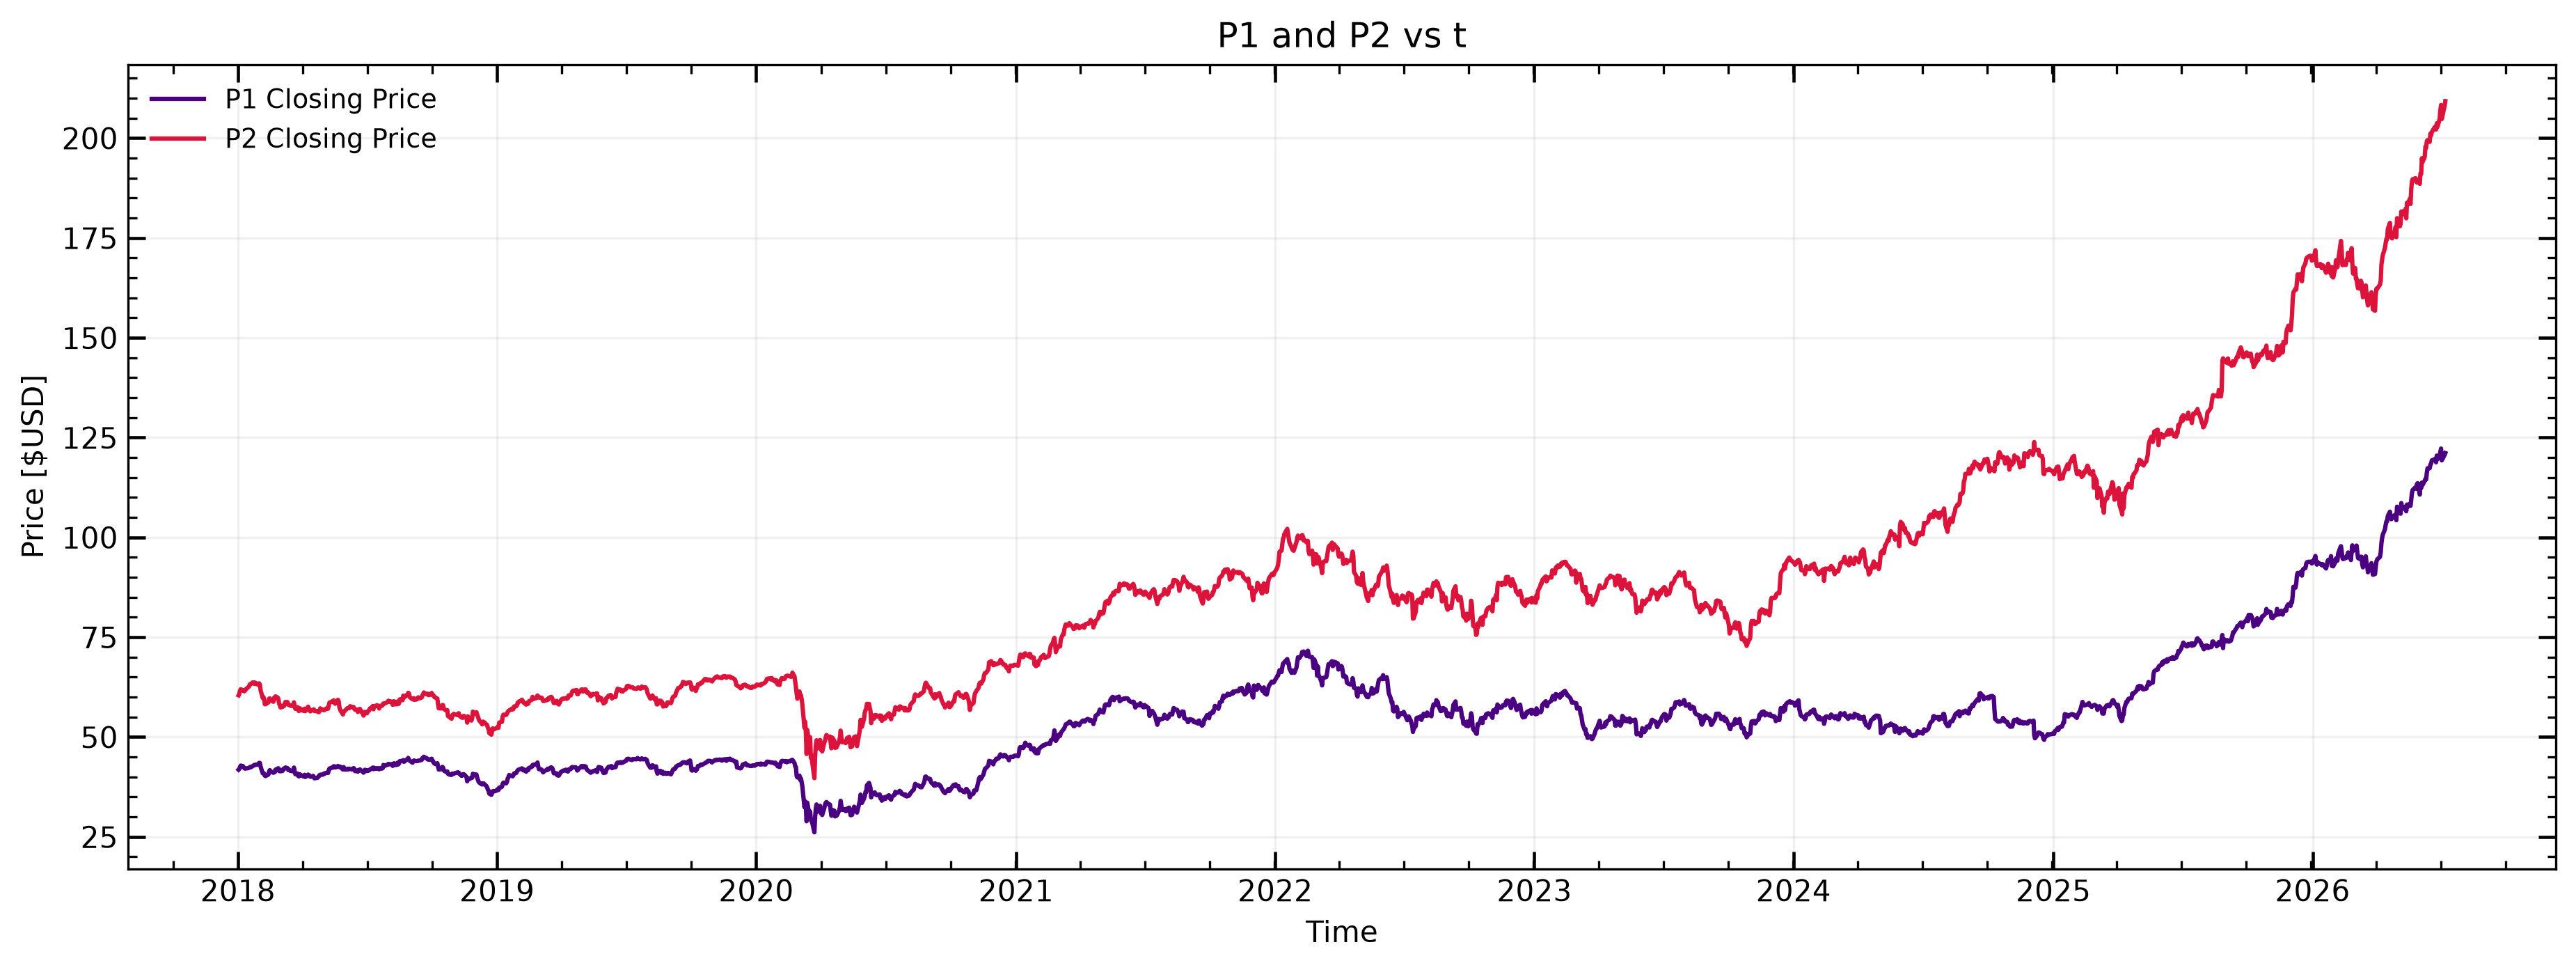

In [10]:
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.plot(P1['Close'], color='indigo', label = 'P1 Closing Price')
ax.plot(P2['Close'], color='crimson', label = 'P2 Closing Price')
ax.set_title('P1 and P2 vs t')
ax.set_ylabel('Price [$USD]')
ax.set_xlabel('Time')

ax.legend(frameon=False, fontsize=9, loc="best")

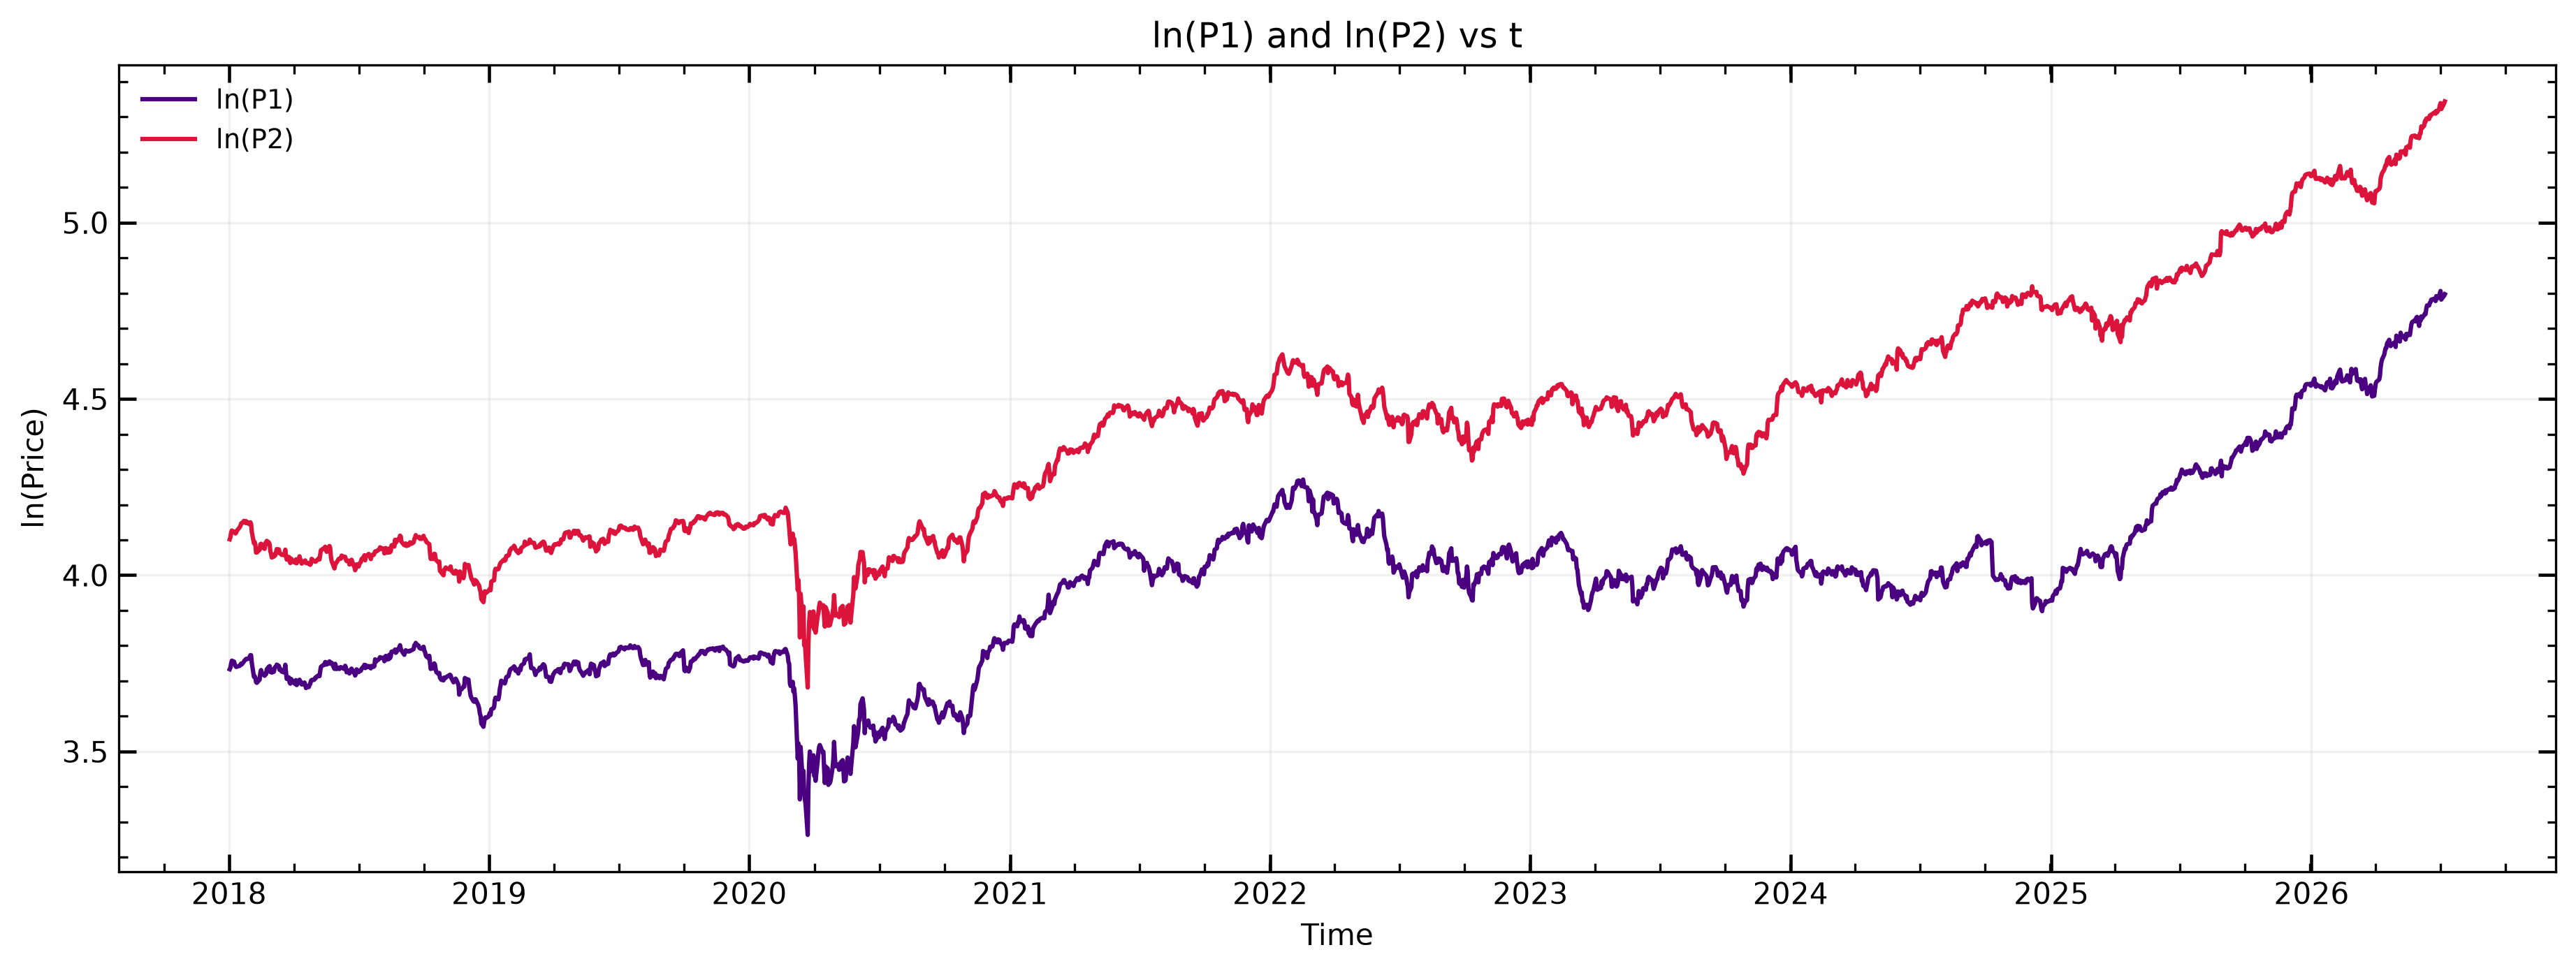

In [15]:
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.plot(df['P1'], color='indigo', label = 'ln(P1)')
ax.plot(df['P2'], color='crimson', label = 'ln(P2)')
ax.set_title('ln(P1) and ln(P2) vs t')
ax.set_ylabel('ln(Price)')
ax.set_xlabel('Time')

ax.legend(frameon=False, fontsize=9, loc="best")

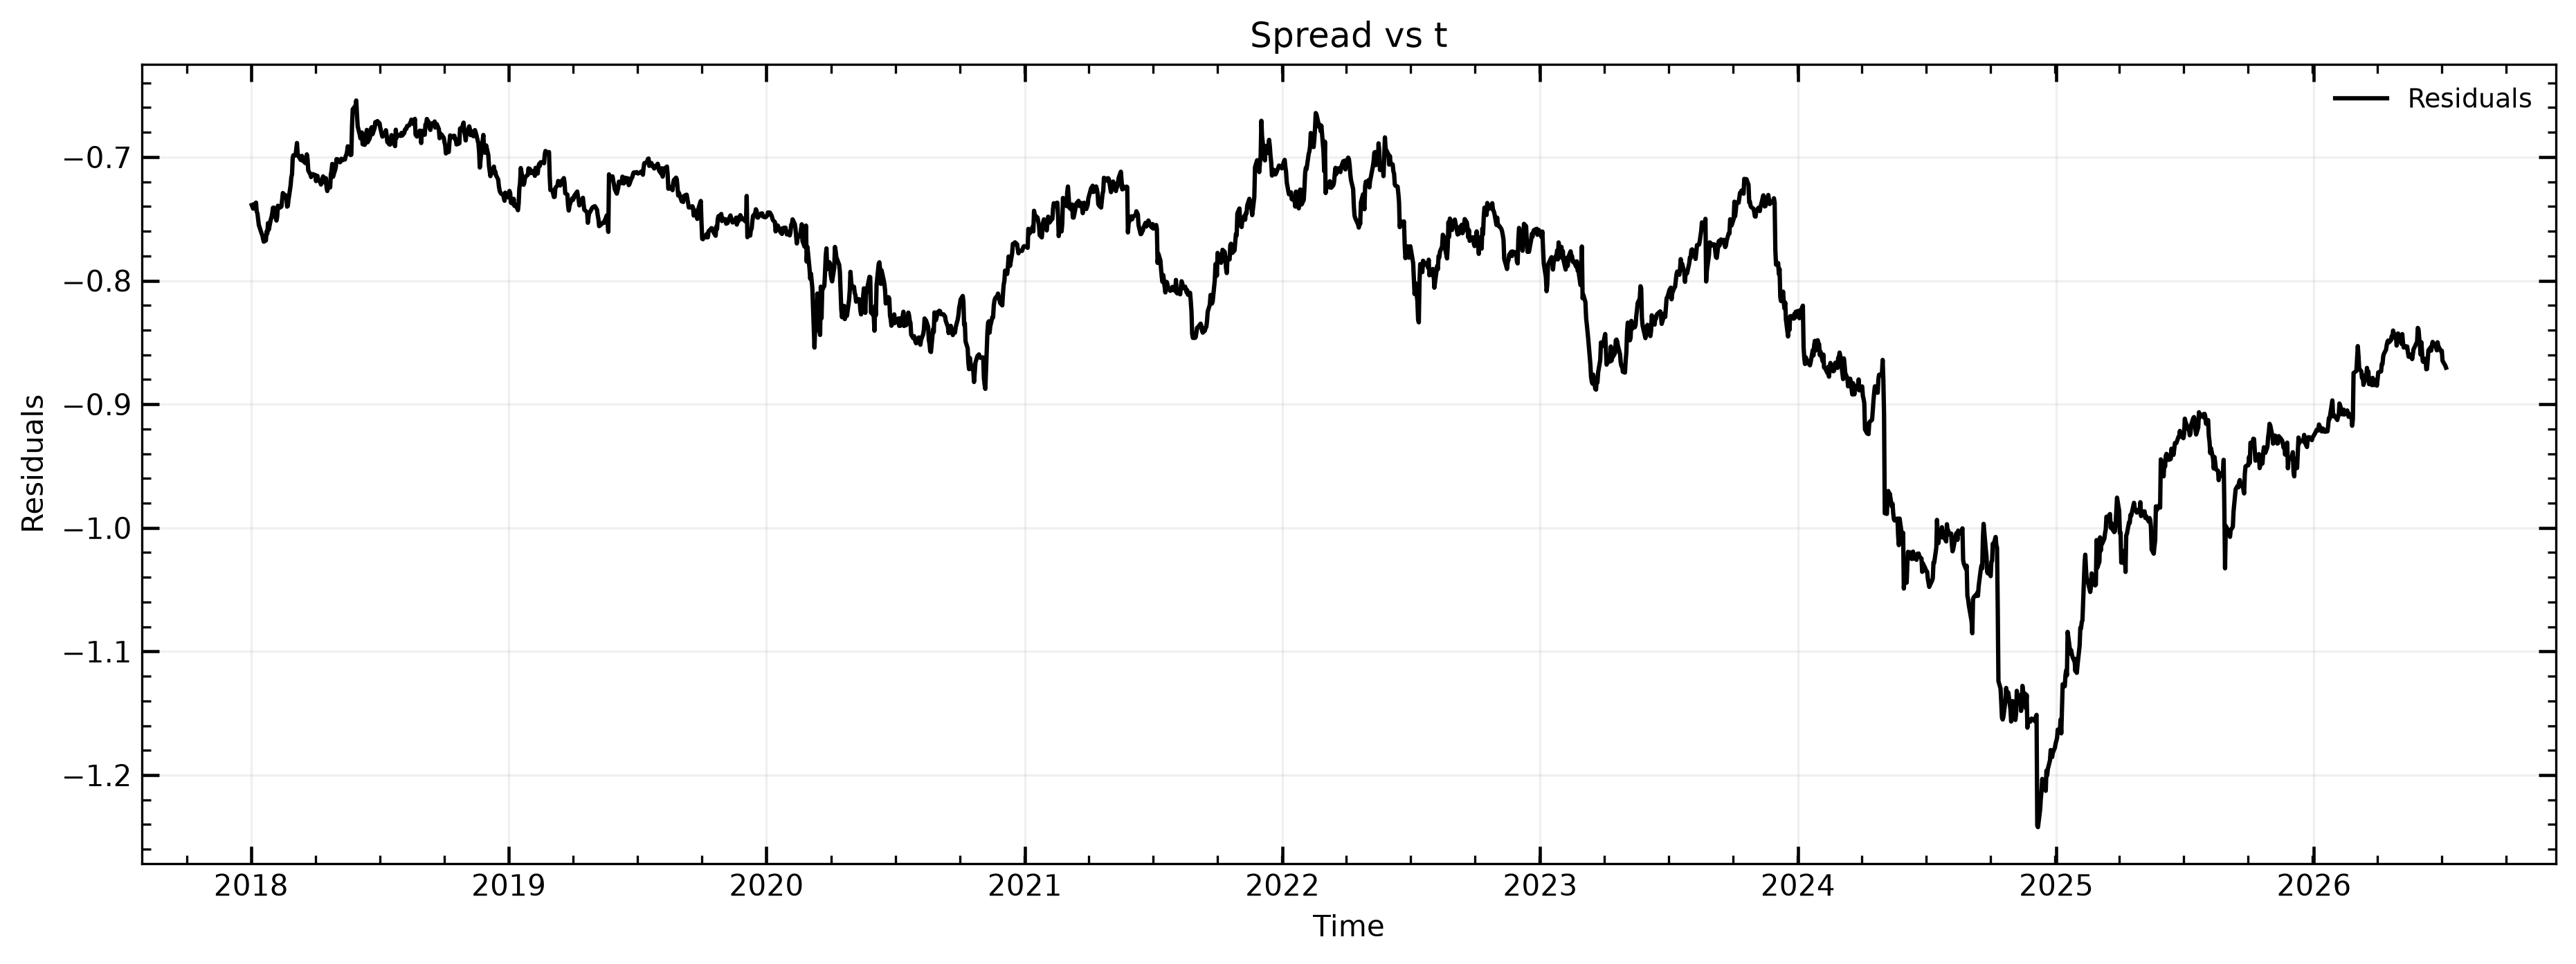

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.plot(df['Spread'], color='teal', label = 'Residuals')
ax.set_title('Spread vs t')
ax.set_ylabel(r'Residuals')
ax.set_xlabel('Time')

ax.legend(frameon=False, fontsize=9, loc="best")

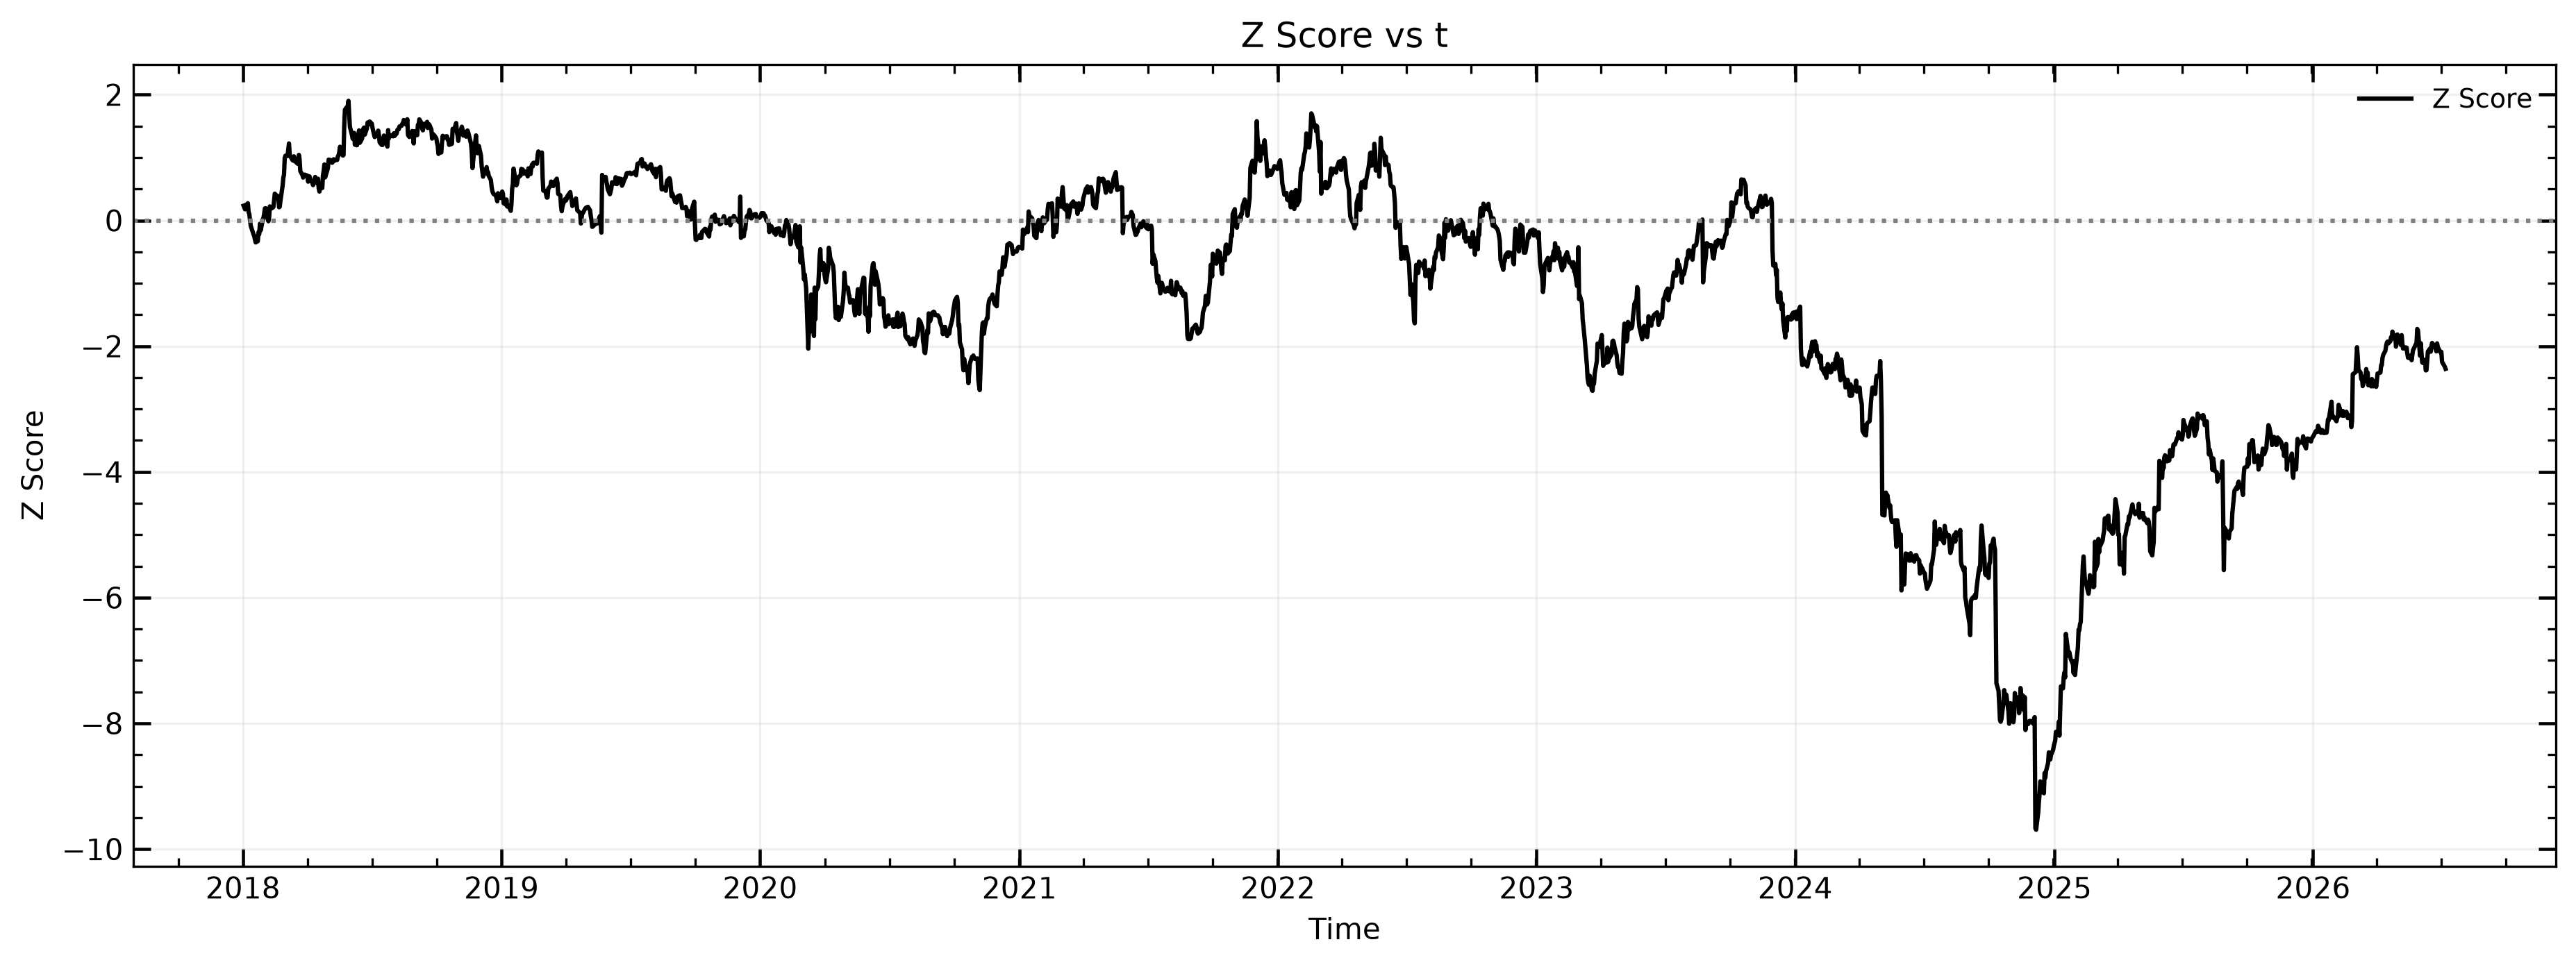

In [19]:
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)

ax.plot(df['z_score'], color='black', label = 'Z Score')
ax.axhline(0.0, ls = 'dotted', color = 'gray')
ax.set_title('Z Score vs t')
ax.set_ylabel(r'Z Score')
ax.set_xlabel('Time')

ax.legend(frameon=False, fontsize=9, loc="best")